## Text analysis
### Caption analysis
The captions were constructed as `colour_group_name` + `product_type_name` + `detail_desc`.

Let's investigate how they describe the images. I'm starting with approximating distributions.

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import clip
from clip.simple_tokenizer import SimpleTokenizer
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
import torch
import re
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [2]:
df = pd.read_parquet('../data/processed/articles.parquet')

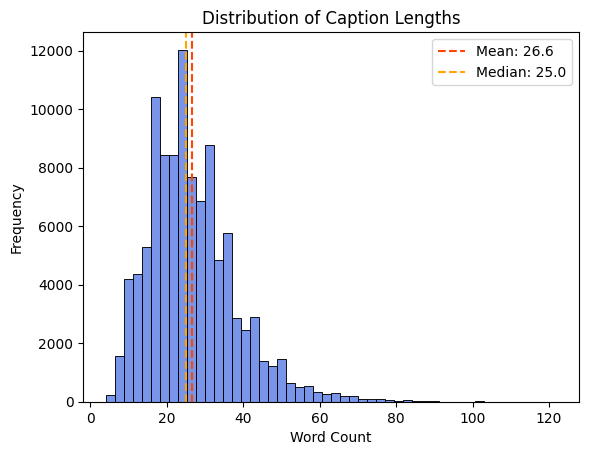

Word count statistics:
Mean: 26.56
Median: 25.00
Std: 11.58
Min: 4
Max: 122


In [7]:
df['caption_len'] = df['caption'].apply(lambda x: len(x.split()))
sns.histplot(df['caption_len'], bins=50, alpha=0.7, color='royalblue')
plt.axvline(x=df['caption_len'].mean(), color='orangered', linestyle='--', label=f"Mean: {df['caption_len'].mean():.1f}")
plt.axvline(x=df['caption_len'].median(), color='orange', linestyle='--', label=f"Median: {df['caption_len'].median():.1f}")
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Caption Lengths')
plt.legend()
plt.show()


print(f"Word count statistics:")
print(f"Mean: {df['caption_len'].mean():.2f}")
print(f"Median: {df['caption_len'].median():.2f}")
print(f"Std: {df['caption_len'].std():.2f}")
print(f"Min: {df['caption_len'].min()}")
print(f"Max: {df['caption_len'].max()}")

The distribution is roughly unimodal, right-skewed, showing tendency to longer captions. The mean is slightly pulled to the right w.r.t. the median. The spread of ~12 words is moderate, but very sparse and very long captions are present, suggesting outliers. 
#### Caption sparsity
Let's investigate sparse outliers and in the next section I will investigate diverse ones. The main question is whether they cluster by product category.

In [8]:
grouped_means = df.groupby('product_type_name')['caption_len'].mean().sort_values()
df_means = grouped_means.reset_index()
df_means['total_items'] = df_means['product_type_name'].apply(
    lambda x: len(df[df['product_type_name'] == x])
)
len(df_means)

131

In [9]:
overall_mean = df['caption_len'].mean()
overall_std = df['caption_len'].std()

product_type_stats = df.groupby('product_type_name').agg({
    'caption_len': ['mean', 'count']
}).round(2)

# Flatten column names
product_type_stats.columns = ['_'.join(col).strip() for col in product_type_stats.columns.values]
product_type_stats = product_type_stats.reset_index()
product_type_stats['z_score'] = (product_type_stats['caption_len_mean'] - overall_mean) / overall_std

# Preserve only statistically sound groups
small_types = product_type_stats[product_type_stats['caption_len_count'] < 100].copy()
big_types = product_type_stats[product_type_stats['caption_len_count'] >= 100].copy()

# Check ~30th percentile
underdescribed = big_types[big_types['z_score'] < -0.5].sort_values('caption_len_mean')

def print_stats(product, score, length, total):
    print(f"{product:35} | Mean length: {length:5.1f} | z-score: {score:5.1f} | Total items: {total:6}")

underdescribed.apply(
    lambda x: print_stats(x['product_type_name'], x['z_score'], x['caption_len_mean'], x['caption_len_count']),
    axis=1
)
print('-' * 60)
print(f"Underdescribed types (30th percentile) number: {len(underdescribed)}")

Hair string                         | Mean length:  11.7 | z-score:  -1.3 | Total items:    234
Ring                                | Mean length:  12.3 | z-score:  -1.2 | Total items:    236
Bracelet                            | Mean length:  13.4 | z-score:  -1.1 | Total items:    170
Underwear Tights                    | Mean length:  14.5 | z-score:  -1.0 | Total items:    543
Socks                               | Mean length:  14.6 | z-score:  -1.0 | Total items:   1877
Sunglasses                          | Mean length:  14.7 | z-score:  -1.0 | Total items:    572
Scarf                               | Mean length:  15.0 | z-score:  -1.0 | Total items:   1012
Hair clip                           | Mean length:  15.5 | z-score:  -1.0 | Total items:    242
Hair/alice band                     | Mean length:  15.7 | z-score:  -0.9 | Total items:    835
Earring                             | Mean length:  16.2 | z-score:  -0.9 | Total items:   1150
T-shirt                             | Me

Small ($<100$ items) categories are cut off for better statistical approximation, so that $z$-score behaves more like a normal variable.

The threshold on $z$-score is set to $<-0.5$, which is approximately 30th percentile, given it's normal.

No $z$-score goes below -1.3, which is 10th percentile, so no category (big enough) is severly underdescribed.

Sparsity is domain-appropriate, structural. Accessories and small items are present extensively, which is natural: e.g., a sock (mean 14.5) is described by material, pattern, length, all can by expressed within 14 words, longer description would introduce semantic redundancy. Garments tend to have greater $z$-score. Overall structural sparsity is mild.

In [10]:
portion = small_types['caption_len_count'].sum() / product_type_stats['caption_len_count'].sum()
print('The portion of items in small types relative to the dataset:')
print(f"{portion:0.2f}%")

The portion of items in small types relative to the dataset:
0.01%


Excluded small types are not representative by item count. Statistical analysis covers virtually all of the dataset.

#### Token truncation analysis
The main concern with diverse outliers is not their vocabulary size, which will be studied later on `detail_desc` alone, but their length. This is since CLIP has a constraint on the number of tokens in a sequence, namely, it should not exceed 77 tokens, longer sequences are truncated. Then captions are the "worst-case" values we can feed to a model.
Since word count is a lower bound on token count, I will now estimate the distribution of tokenized sequences and the effect of their truncation.

In [11]:
tokenizer = SimpleTokenizer()

df['tokenized_caption'] = df['caption'].apply(lambda x: tokenizer.encode(x))
df['token_count'] = df['tokenized_caption'].apply(lambda x: len(x))

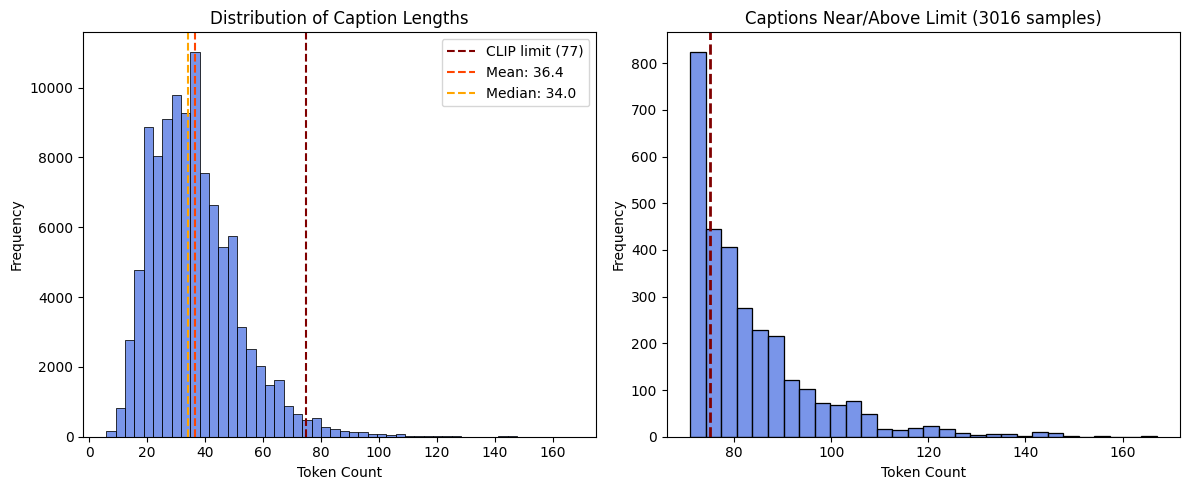

Token count statistics:
Mean: 36.42
Median: 34.00
Std: 15.06
Min: 6
Max: 167
Percentage of captions truncated: 1.94%


In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['token_count'], bins=50, alpha=0.7, color='royalblue')
plt.axvline(x=75, color='maroon', linestyle='--', label='CLIP limit (77)')
plt.axvline(x=df['token_count'].mean(), color='orangered', linestyle='--', label=f'Mean: {df["token_count"].mean():.1f}')
plt.axvline(x=df['token_count'].median(), color='orange', linestyle='--', label=f"Median: {df['token_count'].median():.1f}")
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Distribution of Caption Lengths')
plt.legend()

plt.subplot(1, 2, 2)
long_captions = df[df['token_count'] > 70]
sns.histplot(long_captions['token_count'], bins=30, alpha=0.7, color='royalblue')
plt.axvline(x=75, color='maroon', linestyle='--', linewidth=2)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title(f'Captions Near/Above Limit ({len(long_captions)} samples)')

plt.tight_layout()
plt.show()

over_limit = df[df['token_count'] > 75]    # Limit by 75 as this tokenization doesn't include SOS/EOS tokens

print(f"Token count statistics:")
print(f"Mean: {df['token_count'].mean():.2f}")
print(f"Median: {df['token_count'].median():.2f}")
print(f"Std: {df['token_count'].std():.2f}")
print(f"Min: {df['token_count'].min()}")
print(f"Max: {df['token_count'].max()}")
print(f"Percentage of captions truncated: {len(over_limit) / len(df) * 100:.2f}%")

The moderate right skewness persists, the spread is enlarged, but most captions cluster between 20 to 50 tokens.

Only ~2000 captions lose their information, while all other captions are concentrated around the mean and are preserved. The distribution of tokenized caption lengths near the limit shows the fast drop in frequencies, meaning captions with substantial information loss are very rare.  
Intuitively, truncating those sequences should not lead to high loss in information, but CLIP still has bias. If longer sequences are frequent and contain rare information or fine-grained details, truncating them introduces semantic distortion. That is, CLIP's truncation is equivalent to transforming $X$ to $Y = \min(X, X^{(77)})$, where $X^{(77)}$ is $X$ adjusted to this length. The new random variable $Y$ has distorted distribution with a spike at the boundary (at 77 in this case), so the empirical risk changes, thus its minimizer is different. But if tail tokens contain small amount of additional information (e.g., if they exist due to semantic redundancy), truncating them shouldn't hurt much. Formally, if $X_1$ is the first 77 tokens and $X_2$ is tail tokens, $Z$ is the corresponding image, then it's desirable that $I(X_2; Z \mid X_1) = 0$. From it, we have $p(Z \mid X_1, X_2) = p(Z \mid X_1)$ and the Bayes optimal predictor for the full risk satisfies
$$
\arg \min_g \mathbb{E}_{Z \mid X_1, X_2}[\ell(g, Z)] = \arg \min_g \mathbb{E}_{Z \mid X_1}[\ell(g, Z)]
$$
On the other hand, the clipped risk is $\mathbb{E}_{X_1, Z}[\ell(\mathbf{f}[X_1], Z)]$ and its Bayes optimal predictor is
$$
\arg \min_g \mathbb{E}_{Z \mid X_1}[\ell(g, Z)]
$$
So the minimizers coincide given 0 conditional mutual information, but estimating CMI directly is difficult. Instead, it's possible to estimate the sematic signal, which is lost from truncation, by using a model sensitive to semantic redundancy. This is since CLIP's encoder is trained to capture only the vision-relevant subset of textual information, so if a highly sensitive model, which captures all textual information, calculates near 1.0 similarity between full and truncated captions, truncation kills no signal for CLIP whatsoever.

In [13]:
df_long = df[df['token_count'] > 75].copy()    # Limit by 75 as this tokenization doesn't include SOS/EOS tokens

def create_truncated_text(tokens, tokenizer):
    truncated_tokens = tokens[:75]
    return tokenizer.decode(truncated_tokens)

df_long['full_text'] = df_long['tokenized_caption'].apply(lambda x: tokenizer.decode(x))
df_long['truncated_text'] = df_long['tokenized_caption'].apply(lambda x: create_truncated_text(x, tokenizer))

In [14]:
model = SentenceTransformer('all-MiniLM-L6-v2')

full_embeddings = model.encode(df_long['full_text'].tolist(), convert_to_tensor=True)
trunc_embeddings = model.encode(df_long['truncated_text'].tolist(), convert_to_tensor=True)

similarities = util.cos_sim(full_embeddings, trunc_embeddings)
similarities = torch.diag(similarities).cpu().numpy()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


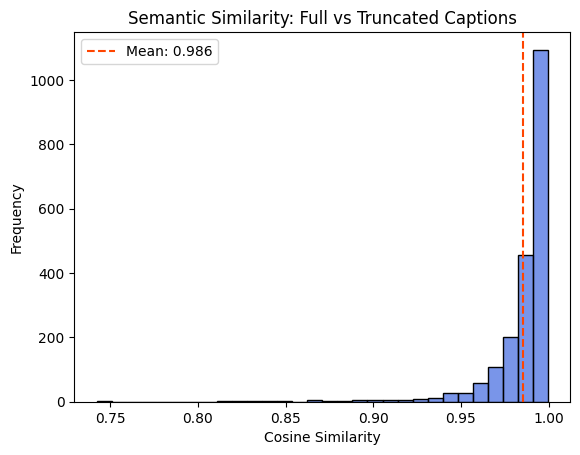

Semantic Information Retained:
Mean similarity: 0.9857
Median similarity: 0.9917
Std: 0.0195
Min: 0.7424
Max: 0.9996


In [15]:
sns.histplot(similarities, bins=30, alpha=0.7, color='royalblue')
plt.axvline(similarities.mean(), color='orangered', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Semantic Similarity: Full vs Truncated Captions')
plt.legend()
plt.show()

print(f"Semantic Information Retained:")
print(f"Mean similarity: {similarities.mean():.4f}")
print(f"Median similarity: {np.median(similarities):.4f}")
print(f"Std: {similarities.std():.4f}")
print(f"Min: {similarities.min():.4f}")
print(f"Max: {similarities.max():.4f}")

The distribution is almost degenerate, decays fast leftward as $\propto 1/2$. Similarity is peaked near 1.0, the mean is slightly pulled to the left, but stays close to 1.0, signifying that, on average, semantic distortion is negligible. Standard deviation is small, most truncations are harmless. Hence, the truncated parts are mostly redundancy.
### Description analysis
Captions are descriptions, augmented in a predictable way by categorical `colour_group_name` and `product_type_name`. Thus, analyzing descriptions is what valuable for textual understanding.

First, cleaning.

In [9]:
def clean_desc(desc):
    desc = desc.lower()
    desc = re.sub(r"[^\w\s-]", ' ', desc)
    desc = ' '.join(desc.split())
    return desc 

df['desc_clean'] = df['detail_desc'].apply(clean_desc)

Now let's count unique words in the vocabulary.

In [5]:
words = ' '.join(df['desc_clean']).split()
vocab_size = len(set(words))

In [6]:
total_descriptions = len(df)
avg_words_per_desc = df['desc_clean'].str.split().str.len().mean()
words_total = df['desc_clean'].str.split().str.len().sum()

print(f"Descriptions: {total_descriptions}")
print(f"Avg words/desc: {avg_words_per_desc:.1f}")
print(f"Total words: {words_total}")
print(f"Vocab size: {vocab_size}")
print(f"Type-token ratio: {vocab_size/words_total:.4f}")

Descriptions: 104696
Avg words/desc: 24.0
Total words: 2509953
Vocab size: 4603
Type-token ratio: 0.0018


TTR is low, indicating repetitive vocabulary and possibly entire descriptions. OOV words should be very infrequent.
#### Ngrams

In [7]:
def get_top_ngrams(corpus, ngram_range, n):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    word_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)
    return word_freq[:n]

top_unigrams = get_top_ngrams(df['desc_clean'], (1,1), 20)
top_bigrams = get_top_ngrams(df['desc_clean'], (2,2), 20)
top_trigrams = get_top_ngrams(df['desc_clean'], (3,3), 20)

In [24]:
def get_df_ngrams(ngrams_list, words_total):
    df = pd.DataFrame(ngrams_list, columns=['ngram', 'count'])
    df['freq'] = (df['count'] / words_total * 100).round(2)
    return df

get_df_ngrams(top_unigrams, words_total)

,ngram,count,freq
0,and,162798,6.49
1,with,150239,5.99
2,the,135748,5.41
3,in,109512,4.36
4,at,80465,3.21
5,back,36721,1.46
6,front,36215,1.44
7,soft,35530,1.42
8,waist,34342,1.37
9,cotton,34240,1.36


Words like "back", "front", "waist", "sleeves" appear high, descriptions are systematically about garment parts and their properties ("long") as well as materials ("cotton", "jersey") and their properties ("soft", "elasticated"). Colors are missing, supporting the hypothesis that they are absent entirely in `detail_desc`. Let's search for the some of the most dominant ones.

In [9]:
colors = [r'\bblack\b', r'\bdark blue\b', r'\bwhite\b', r'\blight pink\b', r'\bgrey\b', r'\blight beige\b']
for color in colors:
    count = df['desc_clean'].str.contains(color).sum()
    print(f"{count:6,} ({count/len(df)*100:5.2f}%)")

    22 ( 0.02%)
     0 ( 0.00%)
    48 ( 0.05%)
     0 ( 0.00%)
     1 ( 0.00%)
     0 ( 0.00%)


Colors are almost undescribed.

Style names are also missing, although they may be crucial for queries like "Maxi dress" or "Straight leg jeans", so let's examine some of them directly. 

In [10]:
style_terms = ['a-line', 'bodycon', 'peplum', 'wrap', 'bootcut', 'straight', 'flared',
               'skater', 'midi', 'maxi', 'crop', 'oversized', 'slim', 'tight']

for term in style_terms:
    count = df['desc_clean'].str.contains(term).sum()
    print(f"{term:15}: {count:6,} ({count / len(df) * 100:.1f}%)"

a-line         :    664 (0.6%)
bodycon        :      0 (0.0%)
peplum         :    238 (0.2%)
wrap           :  3,277 (3.1%)
bootcut        :     12 (0.0%)
straight       :  5,491 (5.2%)
flared         :  3,160 (3.0%)
skater         :     59 (0.1%)
midi           :      0 (0.0%)
maxi           :    750 (0.7%)
crop           :    822 (0.8%)
oversized      :    606 (0.6%)
slim           :  3,025 (2.9%)
tight          :  1,270 (1.2%)


So style identifiers are present, but not abundant. Still, queries like "Bodycon dress" or "Midi skirt" will simply return nothing on direct text search, because the unigrams are absent; the tug here is entirely from the vector search over embeddings, the model has to locate the form- and style-fitting object through visual similarity.

This leads to inspection of bigrams and trigrams.

In [25]:
get_df_ngrams(top_bigrams, words_total)

,ngram,count,freq
0,at the,79354,3.16
1,in soft,28802,1.15
2,the back,24391,0.97
3,the front,24255,0.97
4,jersey with,16888,0.67
5,cuffs and,15965,0.64
6,with an,14544,0.58
7,fabric with,13881,0.55
8,cotton jersey,13666,0.54
9,top in,13644,0.54


In [26]:
get_df_ngrams(top_trigrams, words_total)

,ngram,count,freq
0,at the back,23866,0.95
1,at the cuffs,11266,0.45
2,at the waist,11248,0.45
3,down the front,11012,0.44
4,cuffs and hem,10398,0.41
5,at the top,10218,0.41
6,cotton jersey with,9819,0.39
7,at the front,9580,0.38
8,the front and,9374,0.37
9,with an elasticated,8529,0.34


Spatial references ("down the"), materials ("cotton jersey with"), garment parts ("the cuffs") still persist, meaning this corpus relies more on physical construction details than on aesthetic identity. User queries can be quite different from it. Hence, this suggest a specific justification for the hybrid (dense + sparse) search: keywords find construction, vectors find style.
#### Sentiment analysis
While spatial constructions and styles are important, another aspect of user's query might be subjectivity. For example, some queries might look like "Comportable sneakers". The dataset itself contains words like "comfort" or "breathable"; a simple sentiment analysis will help understand their prevalence and whether the model will learn to align them with visual features. However, care must be exercised to prevent false positives as in the "vest top" versus "top product". For that, I will apply part-of-speach filtering, which should discard obvious false positives, but words like "transparent" will persist, then I will use VADER to assess sentiment. This approach gives only an upper bound on the sentiment count.

Obviously, I will analyze only positive sentiment, since negative sentimental words are unexpected in marketing descriptions. Negative analysis could only cause more false positives. 

In [10]:
nlp = spacy.load('en_core_web_sm')
sid = SentimentIntensityAnalyzer()

vader_positive_words = {word for word, score in sid.lexicon.items() 
                        if score > 0}

texts = df['desc_clean'].tolist()

sentim_words = []

for doc in nlp.pipe(texts, batch_size=1000, disable=['ner', 'parser']):
    row_tokens = []
    for token in doc:
        if token.pos_ in ('ADJ', 'ADV'):
            if token.text in vader_positive_words:
                row_tokens.append(token.lemma_)
    sentim_words.append(row_tokens)

df['sentim_tokens'] = sentim_words

Now that we have some sentiment words, let's calculate statistics.

In [12]:
df['sentim_words_count'] = df['sentim_tokens'].apply(lambda x: len(x))
df['has_sentiment'] = df['sentim_words_count'] > 0

In [14]:
print(f"Descriptions with sentiment words: {df['has_sentiment'].sum() / len(df) *100:.1f}%")
print(f"Avg sentiment words per description: {df['sentim_words_count'].mean():.2f}")
print(f"Max sentiment words in one description: {df['sentim_words_count'].max()}")

Descriptions with sentiment words: 25.6%
Avg sentiment words per description: 0.32
Max sentiment words in one description: 6


Since 25.6% is an upper-bound, being conservative, we can suppose that the actual count is aroung 20k descriptions.

Let's check, whether it clusters within product types.

In [26]:
sentim_by_product = df.groupby('product_type_name')['has_sentiment'].agg(
    sentiment_rate='mean',
    total_items='count'
).sort_values('sentiment_rate', ascending=False)
print("Top 10 products with sentiment:")
print(sentim_by_product[sentim_by_product['total_items'] > 50].head(20))

Top 10 products with sentiment:
                   sentiment_rate  total_items
product_type_name                             
Socks                    0.641449         1877
Outdoor overall          0.640625           64
Underwear Tights         0.541436          543
Shirt                    0.514580         3395
Cardigan                 0.451006         1541
Underwear body           0.450292          171
Bra                      0.439745         2199
Jumpsuit/Playsuit        0.415867         1147
Trousers                 0.393849        11121
Bag                      0.388365         1272
Blazer                   0.379964         1108
Dungarees                0.350649          308
Dress                    0.337054        10304
Sweater                  0.326317         9264
Gloves                   0.325137          366
                         0.322314          121
Blouse                   0.315657         3960
Pyjama set               0.301786         1120
Bikini top               0.2

Garments (especially undergarments) are high in the list, which is natural, since their perceived value is often sentimental (they must be comfortable to the body, for example).

In [27]:
print("Bottom 10 products with sentiment:")
print(sentim_by_product[sentim_by_product['total_items'] > 50].tail(20))

Bottom 10 products with sentiment:
                    sentiment_rate  total_items
product_type_name                              
Hair clip                 0.066116          242
Hat/brim                  0.064267          389
Hair/alice band           0.053892          835
Scarf                     0.052372         1012
Sandals                   0.045770          721
Heeled sandals            0.045000          200
Underwear bottom          0.040415         2697
Swimwear bottom           0.037094         1294
Bracelet                  0.035294          170
Flip flop                 0.032787          122
Earring                   0.029565         1150
Tailored Waistcoat        0.027397           73
Pumps                     0.026882          186
Hair string               0.025641          234
Cap/peaked                0.024476          572
Wedge                     0.017699          113
Ring                      0.016949          236
Necklace                  0.010676          562
Belt 

Accessories, hats, some footwear are low-sentiment.

Although the sentimental descriptions are moderate in amount, their distribution is logical and domain-specific.